In [1]:
import torch

print("=" * 80)
print("SYSTEM CHECK")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)
else:
    print("WARNING: CUDA GPU is not available.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device          :", device)

SYSTEM CHECK
PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
CUDA version    : 12.8
Device          : cuda


In [2]:
import os
import json
import random
import time
import math
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4

NUM_WORKERS = 2

EARLY_STOPPING_PATIENCE = 100

USE_OVERSAMPLING = True

MODEL_NAME = "ResNet50"

CLASS_NAMES = ["0_No_DR", "1_Mild", "2_Moderate", "3_Severe", "4_Proliferative_DR"]

NUM_CLASSES = len(CLASS_NAMES)

print("Model           :", MODEL_NAME)
print("Image size      :", IMAGE_SIZE)
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", EPOCHS)
print("Learning rate   :", LEARNING_RATE)
print("Weight decay    :", WEIGHT_DECAY)
print("Classes         :", CLASS_NAMES)
print("Oversampling    :", USE_OVERSAMPLING)

Model           : ResNet50
Image size      : 224
Batch size      : 16
Epochs          : 50
Learning rate   : 0.0001
Weight decay    : 0.0005
Classes         : ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
Oversampling    : True


In [5]:
KAGGLE_INPUT = Path("/kaggle/input")

print("Searching for prepared APTOS dataset...")

candidates = []

for p in KAGGLE_INPUT.rglob("*"):
    if p.is_dir():
        if (
            (p / "train").is_dir()
            and (p / "val").is_dir()
            and (p / "test").is_dir()
        ):
            candidates.append(p)

print("\nPossible dataset roots:")

for p in candidates:
    print(" ", p)

if len(candidates) == 0:
    raise FileNotFoundError(
        "Could not find train/val/test directories under /kaggle/input."
    )

DATA_ROOT = candidates[0]

print("\nSelected dataset:")
print(DATA_ROOT)

Searching for prepared APTOS dataset...

Possible dataset roots:
  /kaggle/input/datasets/samjohnstonc/dr-classification/aptos

Selected dataset:
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos


In [6]:
print("=" * 80)
print("DATASET STRUCTURE")
print("=" * 80)

for split in ["train", "val", "test"]:

    split_path = DATA_ROOT / split

    print(f"\n{split.upper()}")

    for cls in CLASS_NAMES:

        class_path = split_path / cls

        if not class_path.exists():
            print(f"  MISSING: {cls}")
        else:
            count = len([
                f for f in class_path.iterdir()
                if f.is_file()
            ])

            print(f"  {cls:<20} {count}")

DATASET STRUCTURE

TRAIN
  0_No_DR              1436
  1_Mild               270
  2_Moderate           738
  3_Severe             141
  4_Proliferative_DR   217

VAL
  0_No_DR              180
  1_Mild               34
  2_Moderate           92
  3_Severe             18
  4_Proliferative_DR   27

TEST
  0_No_DR              180
  1_Mild               34
  2_Moderate           92
  3_Severe             18
  4_Proliferative_DR   27


In [7]:
def count_images(split_path):
    counts = {}
    for cls in CLASS_NAMES:
        class_dir = split_path / cls
        # Check if the directory exists before iterating
        if class_dir.exists():
            counts[cls] = len([f for f in class_dir.iterdir() if f.is_file()])
        else:
            counts[cls] = 0
    return counts

dataset_counts = {}

for split in ["train", "val", "test"]:
    dataset_counts[split] = count_images(DATA_ROOT / split)

count_df = pd.DataFrame(dataset_counts).T

count_df["TOTAL"] = count_df.sum(axis=1)

print(count_df)

       0_No_DR  1_Mild  2_Moderate  3_Severe  4_Proliferative_DR  TOTAL
train     1436     270         738       141                 217   2802
val        180      34          92        18                  27    351
test       180      34          92        18                  27    351


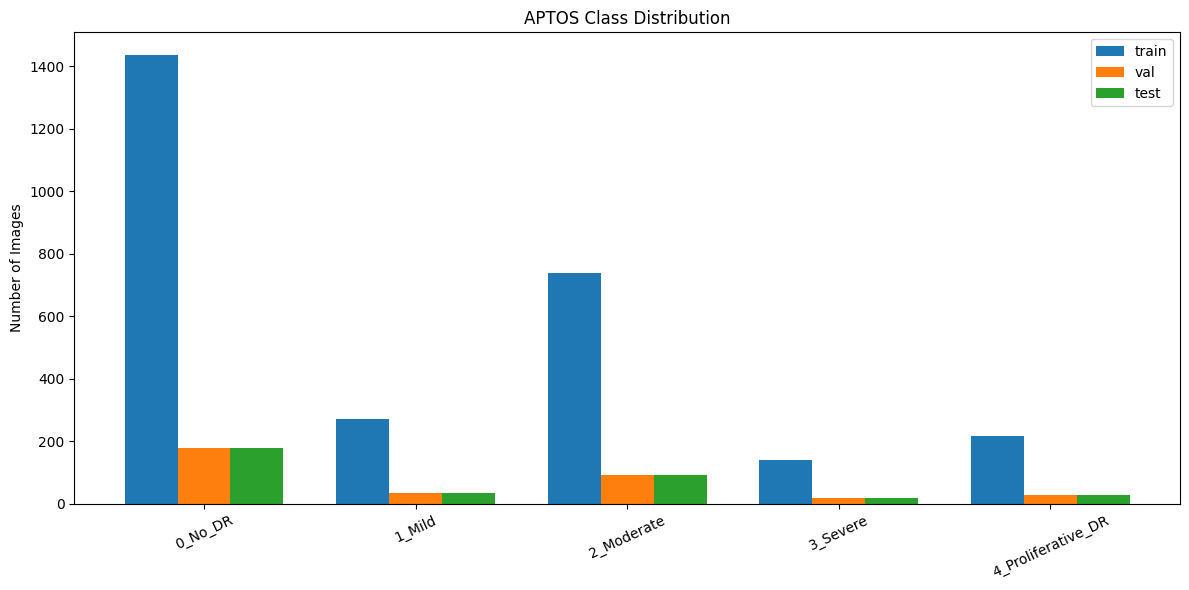

In [8]:
plt.figure(figsize=(12, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.25

for i, split in enumerate(["train", "val", "test"]):

    values = [
        dataset_counts[split][cls]
        for cls in CLASS_NAMES
    ]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=split
    )

plt.xticks(x, CLASS_NAMES, rotation=25)
plt.ylabel("Number of Images")
plt.title("APTOS Class Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomRotation(
        degrees=40
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=0.2,
        scale=(0.8, 1.2)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created.")

Transforms created.


In [10]:
train_dataset = datasets.ImageFolder(
    DATA_ROOT / "train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    DATA_ROOT / "val",
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    DATA_ROOT / "test",
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Train: 2802
Val  : 351
Test : 351

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [11]:
print("Expected class mapping:")
print({
    cls: i
    for i, cls in enumerate(CLASS_NAMES)
})

print("\nActual class mapping:")
print(train_dataset.class_to_idx)

assert train_dataset.class_to_idx == {
    cls: i
    for i, cls in enumerate(CLASS_NAMES)
}, "Class mapping mismatch!"

print("\nClass mapping verified.")

Expected class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

Actual class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

Class mapping verified.


In [12]:
train_targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES
)

print("Original training class counts:")

for i, cls in enumerate(CLASS_NAMES):
    print(
        f"{cls:<20}: {class_counts[i]}"
    )


class_weights = 1.0 / class_counts

sample_weights = np.array([
    class_weights[label]
    for label in train_targets
])

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nWeightedRandomSampler created.")

Original training class counts:
0_No_DR             : 1436
1_Mild              : 270
2_Moderate          : 738
3_Severe            : 141
4_Proliferative_DR  : 217

WeightedRandomSampler created.


In [13]:
if USE_OVERSAMPLING:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True # Added
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True # Added
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True # Added
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True # Added
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 176
Val batches  : 22
Test batches : 22


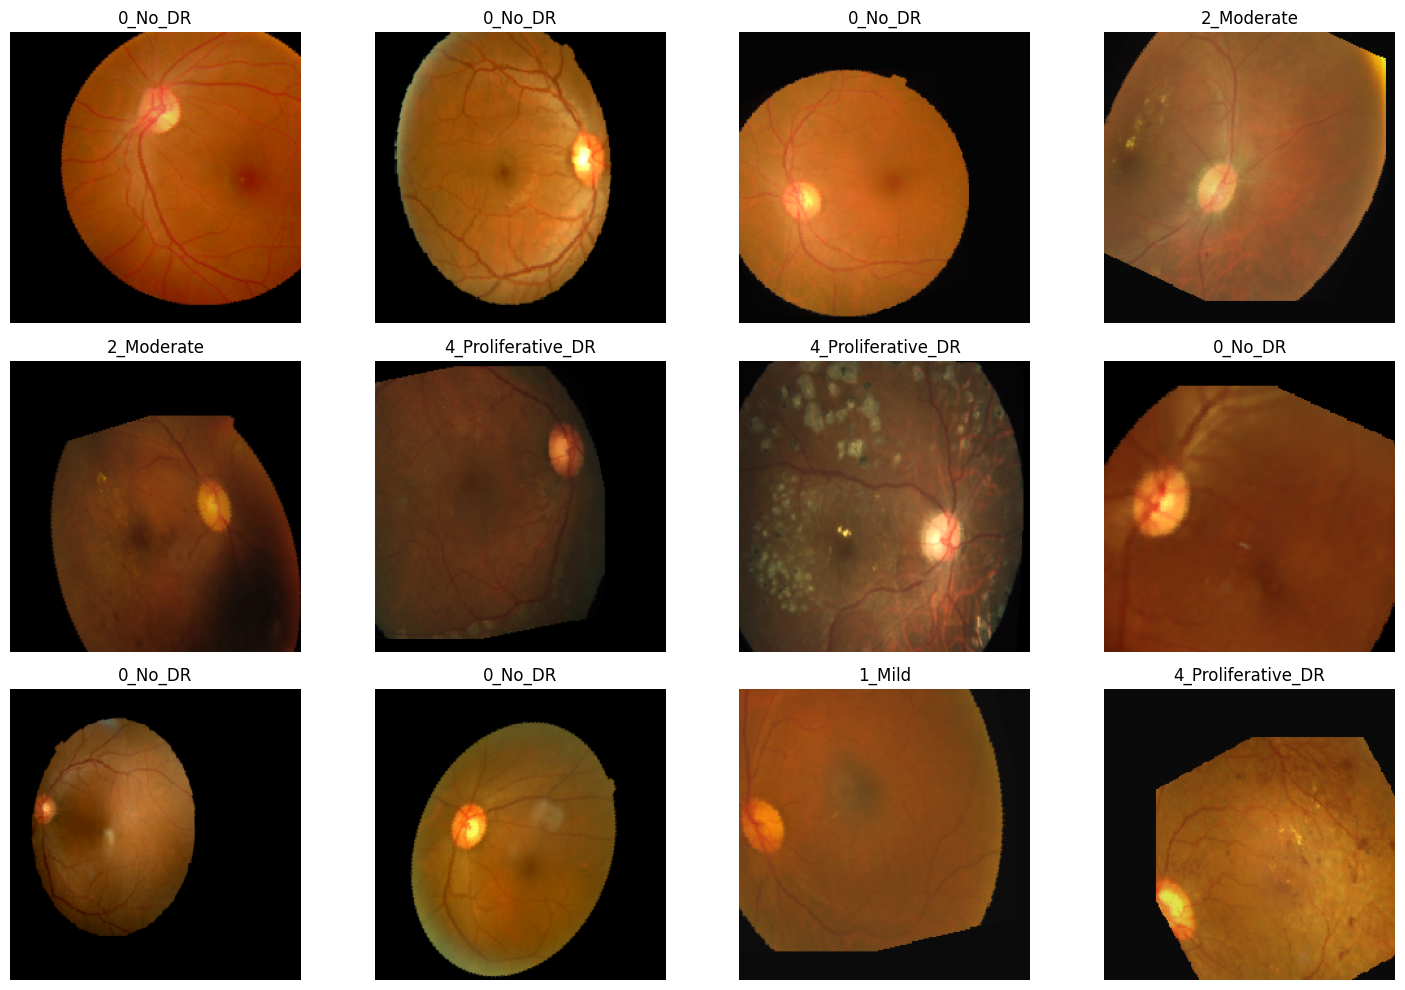

In [14]:
def denormalize(img):

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    img = img * std + mean

    return torch.clamp(img, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 10))

for i in range(min(12, len(images))):

    img = denormalize(images[i])

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        img.permute(1, 2, 0)
    )

    plt.title(
        CLASS_NAMES[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
print("Loading ImageNet-pretrained ResNet50...")

weights = ResNet50_Weights.IMAGENET1K_V2

model = resnet50(
    weights=weights
)

# Replace original ImageNet classifier
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)

Loading ImageNet-pretrained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print("Model              :", MODEL_NAME)
print("Total parameters   :", f"{total_params:,}")
print("Trainable params   :", f"{trainable_params:,}")
print("Device             :", device)

MODEL SUMMARY
Model              : ResNet50
Total parameters   : 23,518,277
Trainable params   : 23,518,277
Device             : cuda


In [17]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [18]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [19]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

print("Scheduler created.")

Scheduler created.


In [20]:
def calculate_basic_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "balanced_accuracy": balanced_acc,
        "cohen_kappa": kappa,
        "mcc": mcc
    }

In [21]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_targets = []

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, targets in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    metrics = calculate_basic_metrics(
        all_targets,
        all_preds
    )

    return epoch_loss, metrics

In [22]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_targets = []

    for images, targets in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            targets
        )

        running_loss += (
            loss.item() *
            images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    metrics = calculate_basic_metrics(
        all_targets,
        all_preds
    )

    return epoch_loss, metrics

In [23]:
RESULTS_DIR = Path(
    "/kaggle/working/resnet50_aptos_results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    RESULTS_DIR /
    "best_resnet50_aptos.pth"
)

print("Results directory:")
print(RESULTS_DIR)

Results directory:
/kaggle/working/resnet50_aptos_results


In [24]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision_macro": [],
    "val_precision_macro": [],
    "train_recall_macro": [],
    "val_recall_macro": [],
    "train_f1_macro": [],
    "val_f1_macro": [],
    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],
    "train_kappa": [],
    "val_kappa": [],
    "train_mcc": [],
    "val_mcc": [],
    "learning_rate": []
}


best_val_f1 = -np.inf
epochs_without_improvement = 0

start_time = time.time()


for epoch in range(1, EPOCHS + 1):

    print("\n" + "=" * 80)
    print(f"EPOCH {epoch}/{EPOCHS}")
    print("=" * 80)

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(
        val_metrics["f1_macro"]
    )

    history["epoch"].append(epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(
        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )

    history["train_precision_macro"].append(
        train_metrics["precision_macro"]
    )

    history["val_precision_macro"].append(
        val_metrics["precision_macro"]
    )

    history["train_recall_macro"].append(
        train_metrics["recall_macro"]
    )

    history["val_recall_macro"].append(
        val_metrics["recall_macro"]
    )

    history["train_f1_macro"].append(
        train_metrics["f1_macro"]
    )

    history["val_f1_macro"].append(
        val_metrics["f1_macro"]
    )

    history["train_balanced_accuracy"].append(
        train_metrics["balanced_accuracy"]
    )

    history["val_balanced_accuracy"].append(
        val_metrics["balanced_accuracy"]
    )

    history["train_kappa"].append(
        train_metrics["cohen_kappa"]
    )

    history["val_kappa"].append(
        val_metrics["cohen_kappa"]
    )

    history["train_mcc"].append(
        train_metrics["mcc"]
    )

    history["val_mcc"].append(
        val_metrics["mcc"]
    )

    history["learning_rate"].append(
        current_lr
    )

    print(
        f"Train Loss       : {train_loss:.4f}"
    )

    print(
        f"Val Loss         : {val_loss:.4f}"
    )

    print(
        f"Train Accuracy   : {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Accuracy     : {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Train Macro F1   : {train_metrics['f1_macro']:.4f}"
    )

    print(
        f"Val Macro F1     : {val_metrics['f1_macro']:.4f}"
    )

    print(
        f"Val Balanced Acc : {val_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Learning Rate    : {current_lr:.8f}"
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_metrics["f1_macro"] > best_val_f1:

        best_val_f1 = val_metrics["f1_macro"]

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_f1": best_val_f1,
                "class_names": CLASS_NAMES,
                "seed": SEED
            },
            CHECKPOINT_PATH
        )

        print(
            f"✓ Best model saved "
            f"(Val Macro-F1 = {best_val_f1:.4f})"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


training_time = (
    time.time() -
    start_time
)

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_f1:.4f}"
)


EPOCH 1/50


Training:   0%|          | 0/176 [00:02<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss       : 1.1634
Val Loss         : 0.5882
Train Accuracy   : 0.5214
Val Accuracy     : 0.7892
Train Macro F1   : 0.5178
Val Macro F1     : 0.6027
Val Balanced Acc : 0.6097
Learning Rate    : 0.00010000
✓ Best model saved (Val Macro-F1 = 0.6027)

EPOCH 2/50


Training:   0%|          | 0/176 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss       : 0.0569
Val Loss         : 0.8018
Train Accuracy   : 0.9829
Val Accuracy     : 0.8319
Train Macro F1   : 0.9831
Val Macro F1     : 0.6670
Val Balanced Acc : 0.6484
Learning Rate    : 0.00000020
No improvement: 40/100

EPOCH 50/50


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss       : 0.0552
Val Loss         : 0.7935
Train Accuracy   : 0.9818
Val Accuracy     : 0.8262
Train Macro F1   : 0.9818
Val Macro F1     : 0.6501
Val Balanced Acc : 0.6299
Learning Rate    : 0.00000010
No improvement: 41/100

TRAINING COMPLETE
Training time: 225.13 minutes
Best validation Macro-F1: 0.7001


In [25]:
history_df = pd.DataFrame(history)

history_csv = (
    RESULTS_DIR /
    "training_history.csv"
)

history_df.to_csv(
    history_csv,
    index=False
)

history_df

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision_macro,val_precision_macro,train_recall_macro,val_recall_macro,train_f1_macro,val_f1_macro,train_balanced_accuracy,val_balanced_accuracy,train_kappa,val_kappa,train_mcc,val_mcc,learning_rate
0,1,1.163378,0.588219,0.521413,0.789174,0.513178,0.648439,0.527794,0.609682,0.517792,0.602678,0.527794,0.609682,0.402211,0.675353,0.403200,0.680831,1.000000e-04
1,2,0.843310,0.547375,0.654532,0.789174,0.651667,0.656261,0.657691,0.676813,0.653802,0.643385,0.657691,0.676813,0.568273,0.679843,0.568634,0.684342,1.000000e-04
2,3,0.693412,0.566662,0.737330,0.789174,0.734203,0.694277,0.738301,0.682256,0.735715,0.659599,0.738301,0.682256,0.671552,0.682772,0.671789,0.694828,1.000000e-04
3,4,0.625982,0.603210,0.761242,0.789174,0.758618,0.657987,0.760866,0.691656,0.759251,0.649182,0.760866,0.691656,0.701456,0.684464,0.701684,0.695871,1.000000e-04
4,5,0.519105,0.550656,0.798715,0.792023,0.797533,0.687908,0.799336,0.674830,0.798308,0.661267,0.799336,0.674830,0.748310,0.685495,0.748375,0.692548,1.000000e-04
5,6,0.489113,0.569401,0.818701,0.800570,0.815048,0.679326,0.816686,0.675070,0.815439,0.655140,0.816686,0.675070,0.773292,0.698631,0.773503,0.707062,1.000000e-04
6,7,0.429167,0.509692,0.845111,0.840456,0.844152,0.689858,0.844779,0.664508,0.844053,0.669026,0.844779,0.664508,0.806259,0.753087,0.806475,0.754076,1.000000e-04
7,8,0.382510,0.584092,0.859029,0.809117,0.858575,0.668874,0.859968,0.733174,0.859183,0.675998,0.859968,0.733174,0.823736,0.716591,0.823782,0.724567,1.000000e-04
8,9,0.337927,0.562520,0.877587,0.826211,0.877536,0.691141,0.878782,0.735150,0.877725,0.700135,0.878782,0.735150,0.846938,0.738983,0.847161,0.744010,1.000000e-04
9,10,0.312326,0.520960,0.886153,0.829060,0.887578,0.695413,0.887156,0.682423,0.887279,0.682414,0.887156,0.682423,0.857610,0.736734,0.857650,0.737437,1.000000e-04


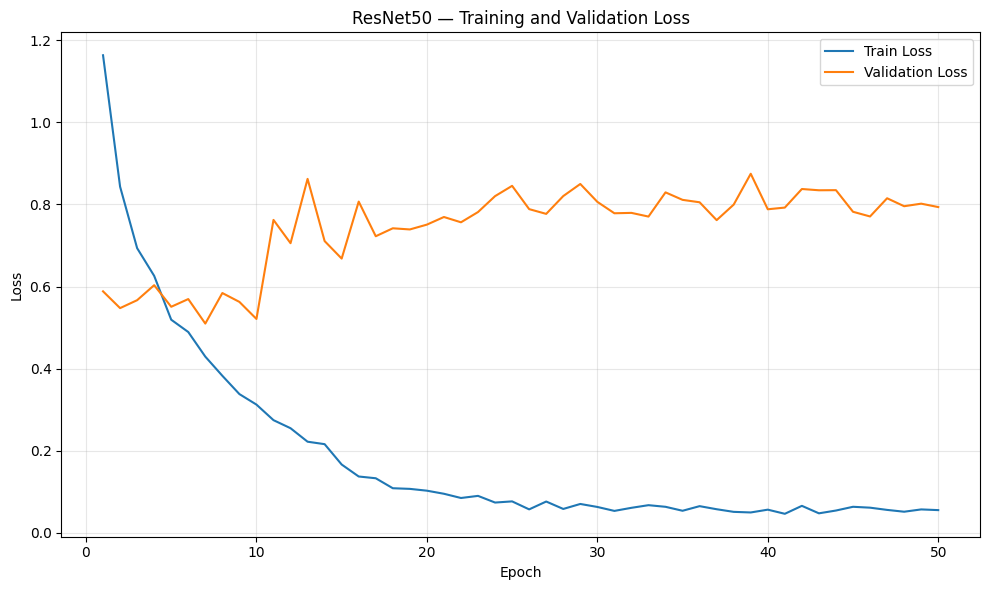

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "loss_curve.png",
    dpi=300
)

plt.show()

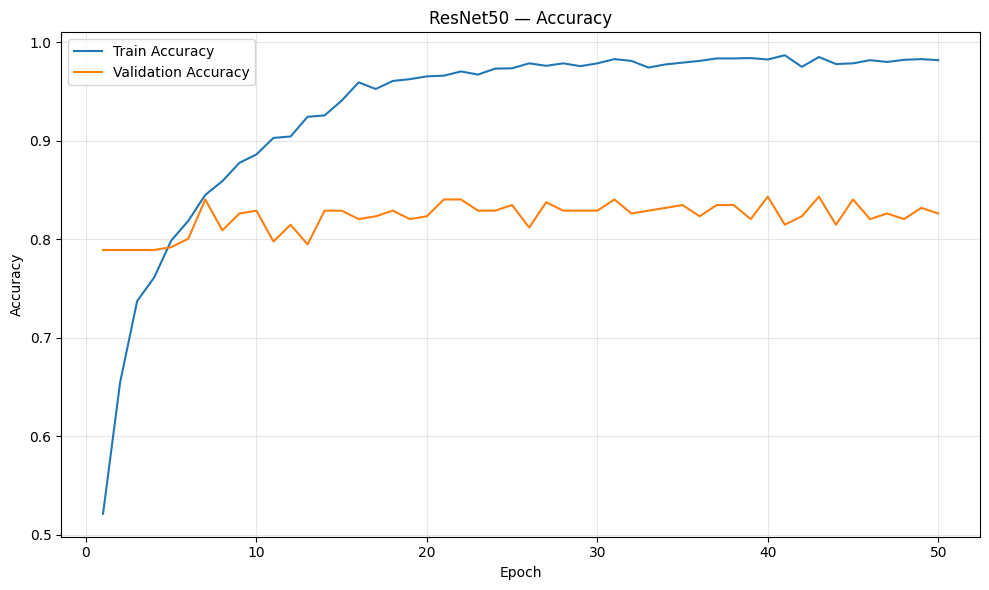

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 — Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "accuracy_curve.png",
    dpi=300
)

plt.show()

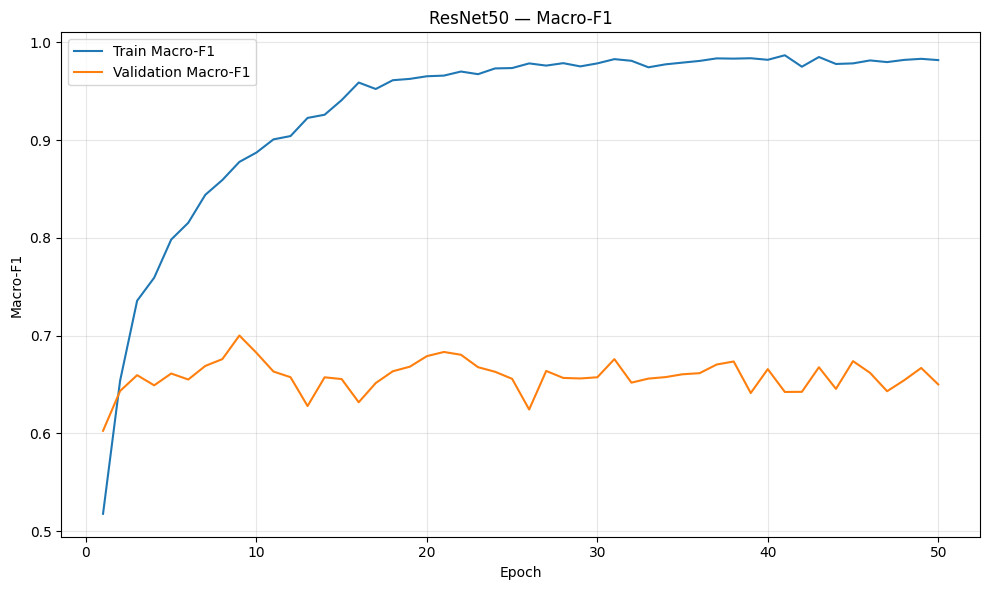

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_f1_macro"],
    label="Train Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("ResNet50 — Macro-F1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "macro_f1_curve.png",
    dpi=300
)

plt.show()

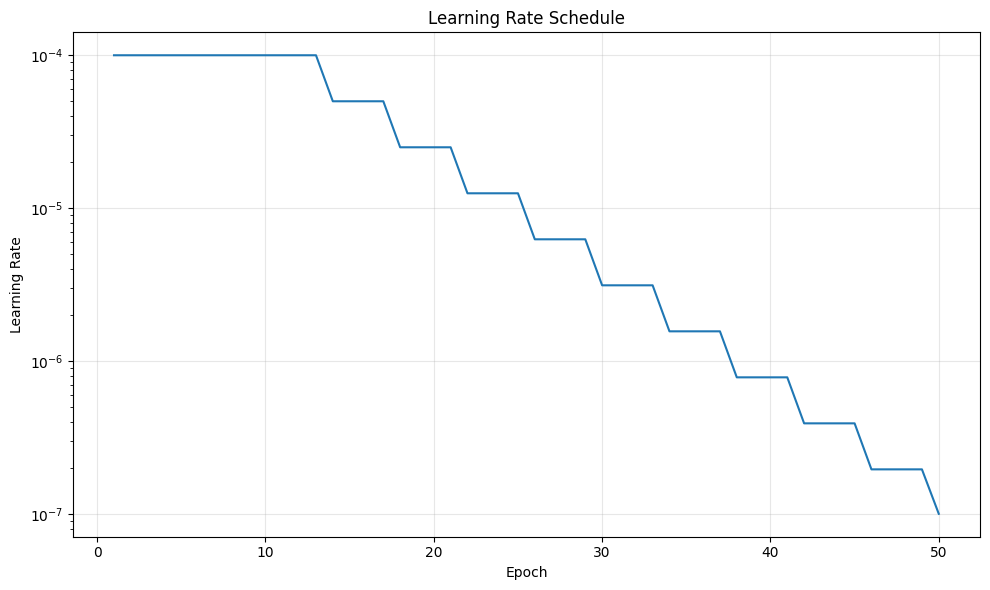

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.yscale("log")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "learning_rate_curve.png",
    dpi=300
)

plt.show()

In [30]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    checkpoint["best_val_f1"]
)

Loaded best checkpoint from epoch: 9
Best validation Macro-F1: 0.7001347685760833


In [31]:
@torch.no_grad()
def get_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_targets = []
    all_preds = []
    all_probs = []
    all_paths = []

    for images, targets in tqdm(
        loader,
        desc="Testing"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probs,
            dim=1
        )

        all_targets.extend(
            targets.numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

    return (
        np.array(all_targets),
        np.array(all_preds),
        np.array(all_probs)
    )

In [32]:
y_true, y_pred, y_prob = get_predictions(
    model,
    test_loader,
    device
)

print("Test samples:", len(y_true))
print("Probability shape:", y_prob.shape)

Testing:   0%|          | 0/22 [00:00<?, ?it/s]

Test samples: 351
Probability shape: (351, 5)


In [33]:
test_metrics = calculate_basic_metrics(
    y_true,
    y_pred
)

metrics_df = pd.DataFrame(
    [test_metrics]
)

metrics_df

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,balanced_accuracy,cohen_kappa,mcc
0,0.809117,0.665281,0.70773,0.681111,0.820661,0.809117,0.811439,0.70773,0.710898,0.712862


In [34]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

classification_df = pd.DataFrame(
    report
).T

classification_df

,precision,recall,f1-score,support
0_No_DR,0.988827,0.983333,0.986072,180.000000
1_Mild,0.533333,0.705882,0.607595,34.000000
2_Moderate,0.746667,0.608696,0.670659,92.000000
3_Severe,0.590909,0.722222,0.650000,18.000000
4_Proliferative_DR,0.466667,0.518519,0.491228,27.000000
accuracy,0.809117,0.809117,0.809117,0.809117
macro avg,0.665281,0.707730,0.681111,351.000000
weighted avg,0.820661,0.809117,0.811439,351.000000


In [35]:
classification_df.to_csv(
    RESULTS_DIR /
    "classification_report.csv"
)

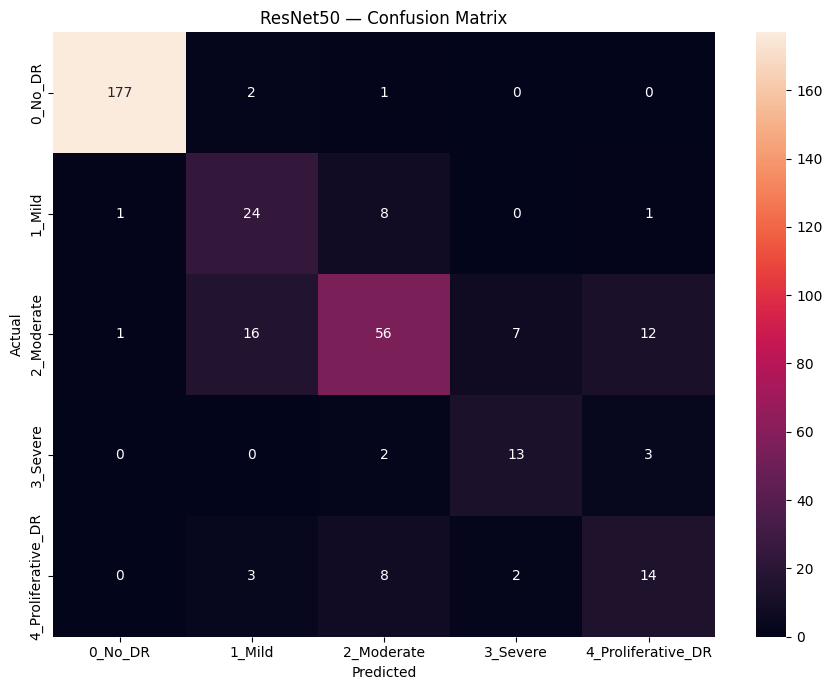

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 — Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "confusion_matrix.png",
    dpi=300
)

plt.show()

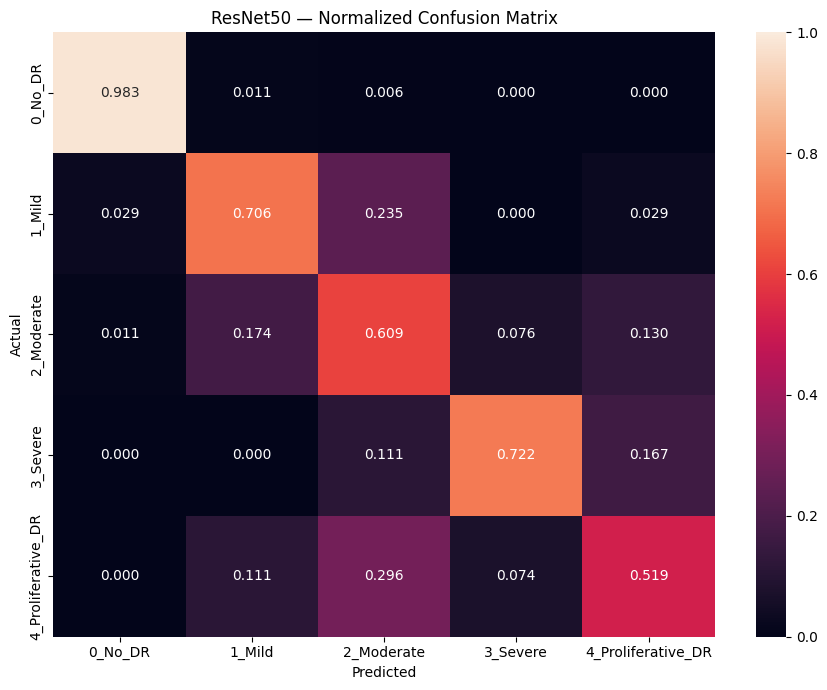

In [37]:
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0,
    vmax=1
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "ResNet50 — Normalized Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "normalized_confusion_matrix.png",
    dpi=300
)

plt.show()

In [38]:
per_class_results = []

for i, cls in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (
        TP + FN + FP
    )

    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    per_class_results.append({

        "Class": cls,

        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,

        "Sensitivity": sensitivity,

        "Specificity": specificity,

        "Precision": precision_score(
            y_true,
            y_pred,
            labels=[i],
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            labels=[i],
            average="macro",
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            labels=[i],
            average="macro",
            zero_division=0
        )
    })


per_class_df = pd.DataFrame(
    per_class_results
)

per_class_df

,Class,TP,TN,FP,FN,Sensitivity,Specificity,Precision,Recall,F1
0,0_No_DR,177,169,2,3,0.983333,0.988304,0.988827,0.983333,0.986072
1,1_Mild,24,296,21,10,0.705882,0.933754,0.533333,0.705882,0.607595
2,2_Moderate,56,240,19,36,0.608696,0.926641,0.746667,0.608696,0.670659
3,3_Severe,13,324,9,5,0.722222,0.972973,0.590909,0.722222,0.650000
4,4_Proliferative_DR,14,308,16,13,0.518519,0.950617,0.466667,0.518519,0.491228


In [39]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

roc_auc_per_class = {}

for i, cls in enumerate(CLASS_NAMES):

    roc_auc_per_class[cls] = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

roc_auc_macro = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print("ROC-AUC Macro   :", roc_auc_macro)
print("ROC-AUC Weighted:", roc_auc_weighted)

print("\nPer-class ROC-AUC:")

for cls, score in roc_auc_per_class.items():
    print(
        f"{cls:<20}: {score:.4f}"
    )

ROC-AUC Macro   : 0.9273390293062423
ROC-AUC Weighted: 0.9573659481246242

Per-class ROC-AUC:
0_No_DR             : 0.9977
1_Mild              : 0.9323
2_Moderate          : 0.9243
3_Severe            : 0.9344
4_Proliferative_DR  : 0.8480


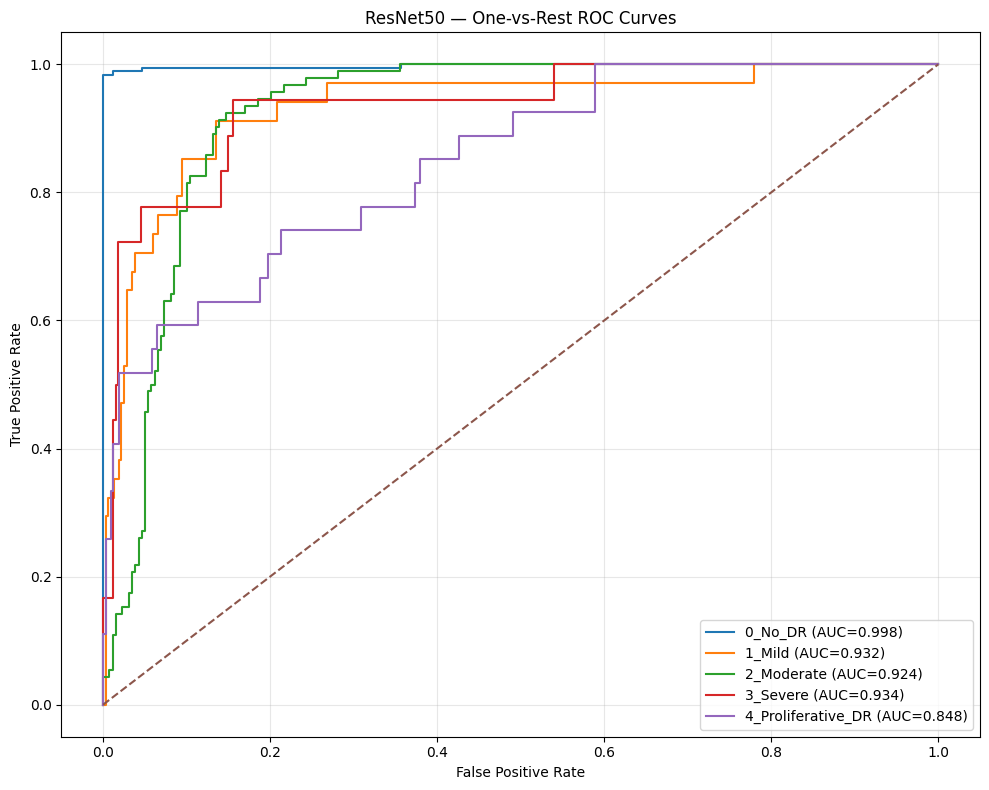

In [40]:
plt.figure(figsize=(10, 8))

for i, cls in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ResNet50 — One-vs-Rest ROC Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "roc_curves.png",
    dpi=300
)

plt.show()

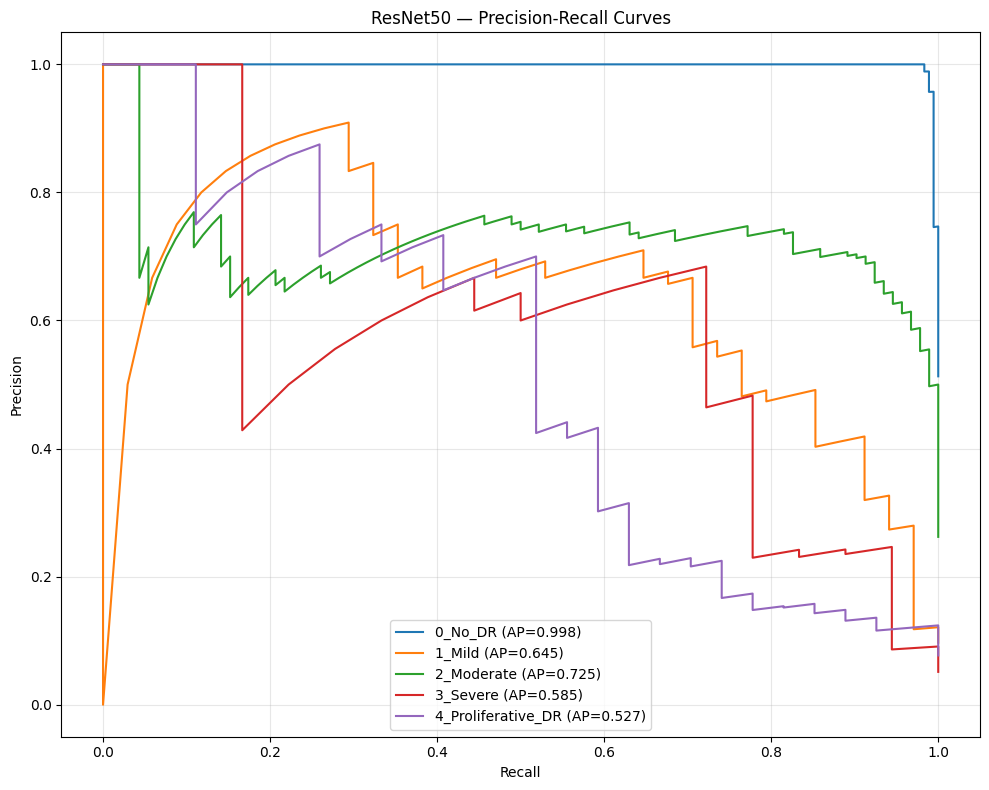

In [41]:
plt.figure(figsize=(10, 8))

for i, cls in enumerate(CLASS_NAMES):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "ResNet50 — Precision-Recall Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "precision_recall_curves.png",
    dpi=300
)

plt.show()

In [42]:
pr_auc_per_class = {}

for i, cls in enumerate(CLASS_NAMES):

    pr_auc_per_class[cls] = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

pr_auc_macro = np.mean(
    list(pr_auc_per_class.values())
)

print("PR-AUC Macro:", pr_auc_macro)

for cls, score in pr_auc_per_class.items():

    print(
        f"{cls:<20}: {score:.4f}"
    )

PR-AUC Macro: 0.6959787555756478
0_No_DR             : 0.9983
1_Mild              : 0.6453
2_Moderate          : 0.7245
3_Severe            : 0.5849
4_Proliferative_DR  : 0.5268


In [43]:
test_log_loss = log_loss(
    y_true,
    y_prob,
    labels=np.arange(NUM_CLASSES)
)

print(
    f"Test Log Loss: {test_log_loss:.6f}"
)

Test Log Loss: 0.620904


In [44]:
brier_scores = {}

for i, cls in enumerate(CLASS_NAMES):

    brier_scores[cls] = brier_score_loss(
        y_true_bin[:, i],
        y_prob[:, i]
    )

brier_df = pd.DataFrame({
    "Class": list(brier_scores.keys()),
    "Brier Score": list(brier_scores.values())
})

brier_df

,Class,Brier Score
0,0_No_DR,0.009835
1,1_Mild,0.055478
2,2_Moderate,0.116703
3,3_Severe,0.034590
4,4_Proliferative_DR,0.064777


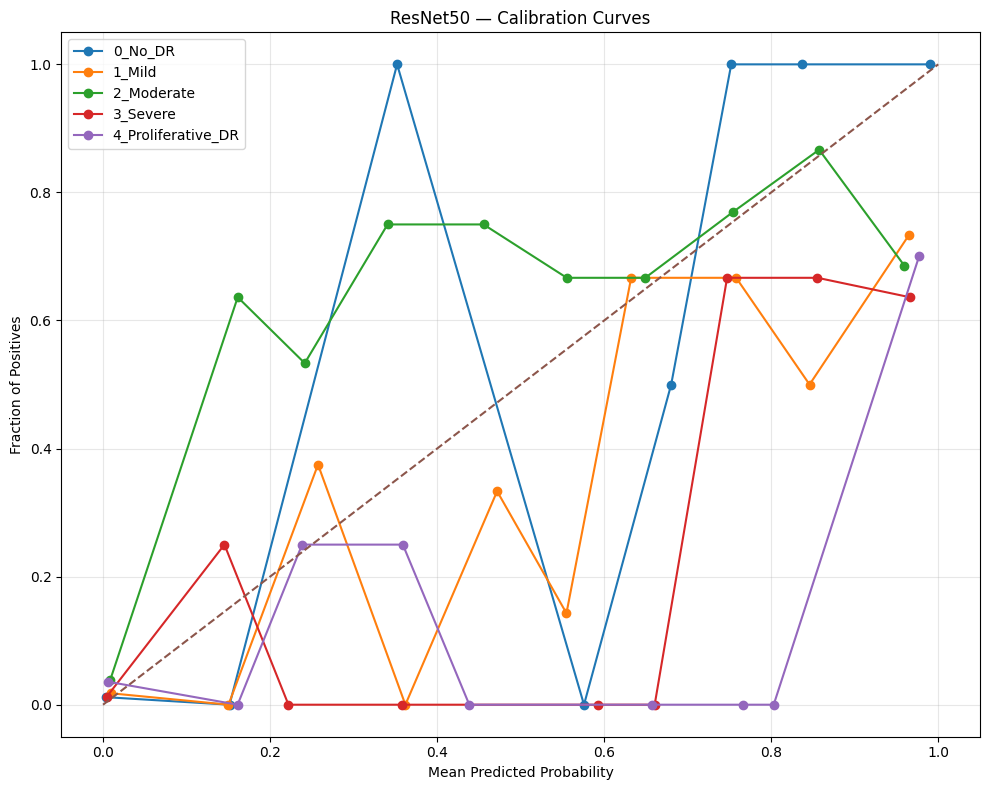

In [45]:
plt.figure(figsize=(10, 8))

for i, cls in enumerate(CLASS_NAMES):

    prob_true, prob_pred = calibration_curve(
        y_true_bin[:, i],
        y_prob[:, i],
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=cls
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.title(
    "ResNet50 — Calibration Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "calibration_curves.png",
    dpi=300
)

plt.show()

In [46]:
confidence = np.max(
    y_prob,
    axis=1
)

correct = (
    y_true == y_pred
)

print(
    "Mean confidence:",
    confidence.mean()
)

print(
    "Correct prediction confidence:",
    confidence[correct].mean()
)

print(
    "Incorrect prediction confidence:",
    confidence[~correct].mean()
)

Mean confidence: 0.9055834
Correct prediction confidence: 0.9381556
Incorrect prediction confidence: 0.7675166


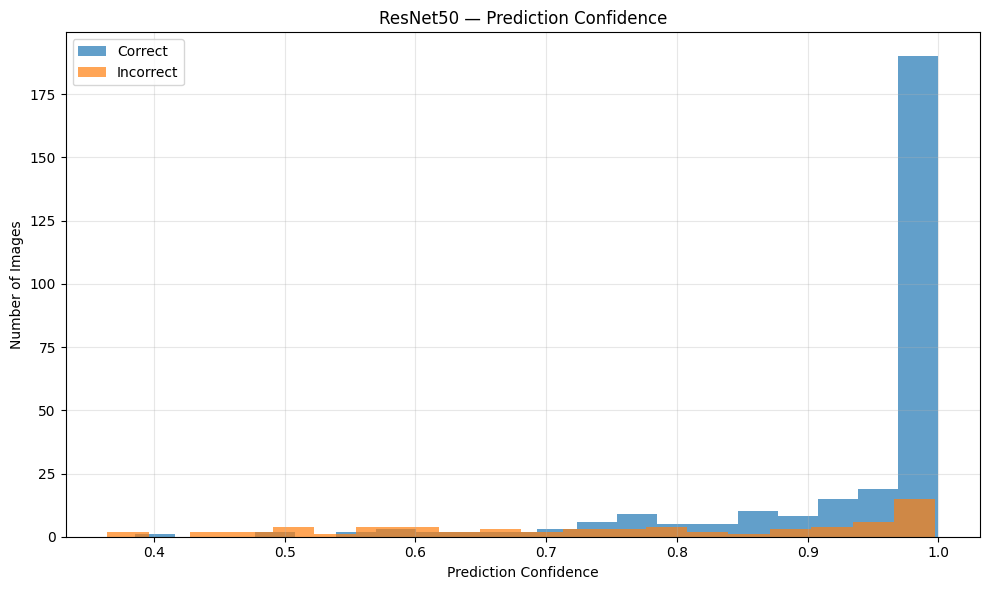

In [47]:
plt.figure(figsize=(10, 6))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")

plt.title(
    "ResNet50 — Prediction Confidence"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "confidence_distribution.png",
    dpi=300
)

plt.show()

In [48]:
test_paths = [
    path
    for path, _ in test_dataset.samples
]

prediction_records = []

for i in range(len(y_true)):

    record = {

        "image_path": test_paths[i],

        "true_label":
            CLASS_NAMES[y_true[i]],

        "predicted_label":
            CLASS_NAMES[y_pred[i]],

        "confidence":
            confidence[i],

        "correct":
            bool(correct[i])
    }

    for j, cls in enumerate(CLASS_NAMES):

        record[
            f"prob_{cls}"
        ] = y_prob[i, j]

    prediction_records.append(
        record
    )


predictions_df = pd.DataFrame(
    prediction_records
)

predictions_df.to_csv(
    RESULTS_DIR /
    "test_predictions.csv",
    index=False
)

predictions_df.head()

,image_path,true_label,predicted_label,confidence,correct,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
0,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,0_No_DR,0.942591,True,0.942591,0.043850,0.005623,0.000537,0.007400
1,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,0_No_DR,0.999860,True,0.999860,0.000022,0.000052,0.000032,0.000034
2,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,0_No_DR,0.994483,True,0.994483,0.005200,0.000221,0.000018,0.000079
3,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,0_No_DR,0.997053,True,0.997053,0.001887,0.000999,0.000042,0.000020
4,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,0_No_DR,0.996547,True,0.996547,0.002484,0.000855,0.000043,0.000071


In [49]:
misclassified_df = predictions_df[
    ~predictions_df["correct"]
].copy()

print(
    "Misclassified:",
    len(misclassified_df)
)

print(
    "Misclassification rate:",
    len(misclassified_df) /
    len(predictions_df)
)

misclassified_df.to_csv(
    RESULTS_DIR /
    "misclassified_images.csv",
    index=False
)

misclassified_df.head(20)

Misclassified: 67
Misclassification rate: 0.1908831908831909


,image_path,true_label,predicted_label,confidence,correct,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
19,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,1_Mild,0.954835,False,3.319797e-02,0.954835,0.010962,0.000162,0.000843
65,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,1_Mild,0.997497,False,3.322183e-04,0.997497,0.002120,0.000018,0.000033
150,/kaggle/input/datasets/samjohnstonc/dr-classif...,0_No_DR,2_Moderate,0.631370,False,3.520803e-01,0.014173,0.631370,0.001035,0.001341
181,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.709690,False,9.357818e-03,0.279028,0.709690,0.000161,0.001763
184,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.952812,False,7.053778e-06,0.036362,0.952812,0.006534,0.004286
188,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.971169,False,8.805499e-03,0.018062,0.971169,0.000560,0.001404
189,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.765375,False,6.013678e-05,0.231335,0.765375,0.001318,0.001912
202,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.510185,False,3.259657e-05,0.479564,0.510185,0.007747,0.002471
204,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,2_Moderate,0.897228,False,1.374311e-04,0.094000,0.897228,0.007925,0.000710
206,/kaggle/input/datasets/samjohnstonc/dr-classif...,1_Mild,0_No_DR,0.575871,False,5.758713e-01,0.422818,0.001285,0.000010,0.000016


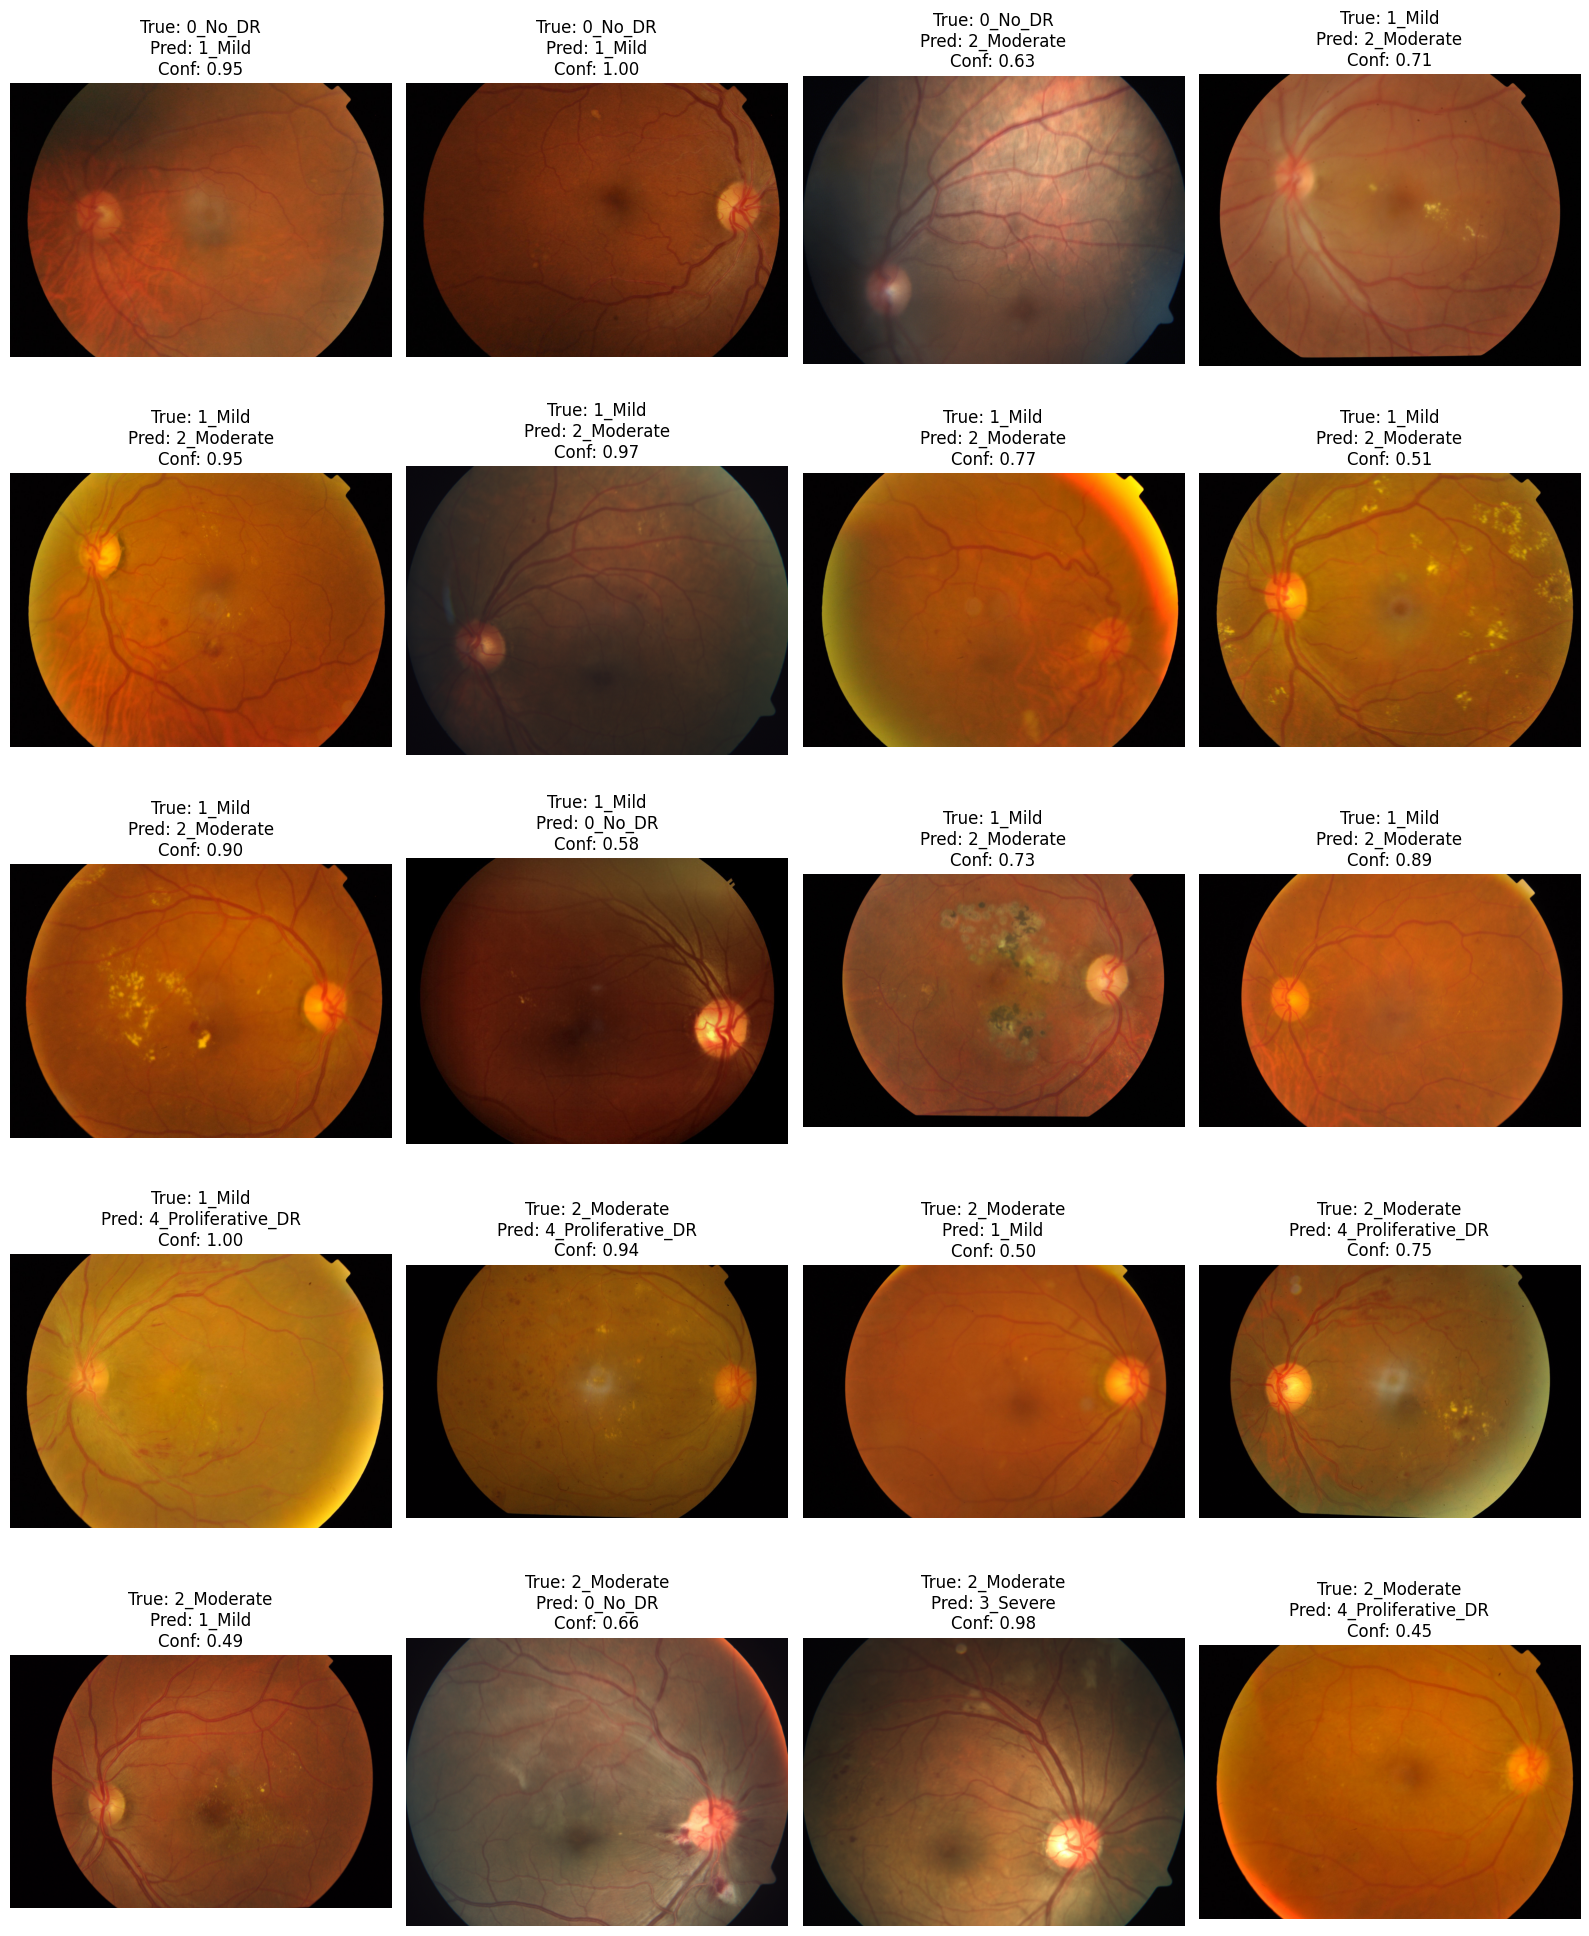

In [50]:
num_images = min(
    20,
    len(misclassified_df)
)

plt.figure(
    figsize=(16, 20)
)

for i in range(num_images):

    row = misclassified_df.iloc[i]

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.subplot(
        5,
        4,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}\n"
        f"Conf: {row['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "misclassified_examples.png",
    dpi=300
)

plt.show()

In [51]:
def bootstrap_metric_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=2000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(y_true)

    scores = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            n
        )

        yt = y_true[indices]
        yp = y_pred[indices]

        try:

            score = metric_func(
                yt,
                yp
            )

            scores.append(score)

        except:

            continue

    scores = np.array(scores)

    lower = np.percentile(
        scores,
        2.5
    )

    upper = np.percentile(
        scores,
        97.5
    )

    return (
        np.mean(scores),
        lower,
        upper
    )

In [52]:
bootstrap_results = {}

metrics_to_bootstrap = {

    "Accuracy":
        lambda yt, yp:
        accuracy_score(yt, yp),

    "Macro Precision":
        lambda yt, yp:
        precision_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

    "Macro Recall":
        lambda yt, yp:
        recall_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

    "Macro F1":
        lambda yt, yp:
        f1_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

    "Balanced Accuracy":
        lambda yt, yp:
        balanced_accuracy_score(
            yt,
            yp
        ),

    "Cohen Kappa":
        lambda yt, yp:
        cohen_kappa_score(
            yt,
            yp
        ),

    "MCC":
        lambda yt, yp:
        matthews_corrcoef(
            yt,
            yp
        )
}


for name, func in metrics_to_bootstrap.items():

    mean_score, lower, upper = (
        bootstrap_metric_ci(
            y_true,
            y_pred,
            func,
            n_bootstrap=2000,
            seed=SEED
        )
    )

    bootstrap_results[name] = {

        "Mean":
            mean_score,

        "CI_lower":
            lower,

        "CI_upper":
            upper
    }


bootstrap_df = pd.DataFrame(
    bootstrap_results
).T

bootstrap_df

,Mean,CI_lower,CI_upper
Accuracy,0.809463,0.769231,0.849003
Macro Precision,0.665899,0.597837,0.733401
Macro Recall,0.708109,0.638913,0.774306
Macro F1,0.678695,0.615001,0.741802
Balanced Accuracy,0.708109,0.638913,0.774306
Cohen Kappa,0.711004,0.656858,0.765433
MCC,0.713538,0.660499,0.768216


In [53]:
bootstrap_df.to_csv(
    RESULTS_DIR /
    "bootstrap_95CI.csv"
)

In [54]:
final_metrics = {

    "Model":
        MODEL_NAME,

    "Dataset":
        "APTOS 2019",

    "Test Samples":
        len(y_true),

    "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

    "Macro Precision":
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro Recall":
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro F1":
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Weighted Precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted Recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted F1":
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_true,
            y_pred
        ),

    "Cohen Kappa":
        cohen_kappa_score(
            y_true,
            y_pred
        ),

    "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        ),

    "ROC-AUC Macro":
        roc_auc_macro,

    "ROC-AUC Weighted":
        roc_auc_weighted,

    "PR-AUC Macro":
        pr_auc_macro,

    "Log Loss":
        test_log_loss,

    "Best Val Macro F1":
        best_val_f1
}


final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df.T

,0
Model,ResNet50
Dataset,APTOS 2019
Test Samples,351
Accuracy,0.809117
Macro Precision,0.665281
Macro Recall,0.70773
Macro F1,0.681111
Weighted Precision,0.820661
Weighted Recall,0.809117
Weighted F1,0.811439


In [55]:
final_metrics_df.to_csv(
    RESULTS_DIR /
    "final_metrics.csv",
    index=False
)

with open(
    RESULTS_DIR /
    "final_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

print(
    "Final metrics saved."
)

Final metrics saved.


In [56]:
per_class_df.to_csv(
    RESULTS_DIR /
    "per_class_metrics.csv",
    index=False
)

print(
    "Per-class metrics saved."
)

Per-class metrics saved.


In [57]:
config = {

    "model":
        MODEL_NAME,

    "dataset":
        "APTOS 2019",

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "optimizer":
        "AdamW",

    "scheduler":
        "ReduceLROnPlateau",

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "oversampling":
        USE_OVERSAMPLING,

    "num_workers":
        NUM_WORKERS,

    "seed":
        SEED,

    "pretrained":
        True,

    "weights":
        "ResNet50_Weights.IMAGENET1K_V2",

    "classes":
        CLASS_NAMES
}


with open(
    RESULTS_DIR /
    "experiment_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved.")

Configuration saved.


In [58]:
print("=" * 80)
print("RESNET50 — APTOS FINAL RESULTS")
print("=" * 80)

for key, value in final_metrics.items():

    if isinstance(value, float):

        print(
            f"{key:<25}: "
            f"{value:.4f}"
        )

    else:

        print(
            f"{key:<25}: "
            f"{value}"
        )

RESNET50 — APTOS FINAL RESULTS
Model                    : ResNet50
Dataset                  : APTOS 2019
Test Samples             : 351
Accuracy                 : 0.8091
Macro Precision          : 0.6653
Macro Recall             : 0.7077
Macro F1                 : 0.6811
Weighted Precision       : 0.8207
Weighted Recall          : 0.8091
Weighted F1              : 0.8114
Balanced Accuracy        : 0.7077
Cohen Kappa              : 0.7109
MCC                      : 0.7129
ROC-AUC Macro            : 0.9273
ROC-AUC Weighted         : 0.9574
PR-AUC Macro             : 0.6960
Log Loss                 : 0.6209
Best Val Macro F1        : 0.7001


In [59]:
print("=" * 80)
print("GENERATED RESULTS")
print("=" * 80)

for file in sorted(RESULTS_DIR.iterdir()):

    if file.is_file():

        size_mb = file.stat().st_size / (
            1024 * 1024
        )

        print(
            f"{file.name:<45} "
            f"{size_mb:.2f} MB"
        )

GENERATED RESULTS
accuracy_curve.png                            0.16 MB
best_resnet50_aptos.pth                       269.59 MB
bootstrap_95CI.csv                            0.00 MB
calibration_curves.png                        0.45 MB
classification_report.csv                     0.00 MB
confidence_distribution.png                   0.09 MB
confusion_matrix.png                          0.15 MB
experiment_config.json                        0.00 MB
final_metrics.csv                             0.00 MB
final_metrics.json                            0.00 MB
learning_rate_curve.png                       0.09 MB
loss_curve.png                                0.18 MB
macro_f1_curve.png                            0.16 MB
misclassified_examples.png                    18.30 MB
misclassified_images.csv                      0.01 MB
normalized_confusion_matrix.png               0.19 MB
per_class_metrics.csv                         0.00 MB
precision_recall_curves.png                   0.26 MB
roc_cur

In [60]:
model.layer4[-1]

Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)